# Tarea final: Boosting aplicado a rotación de clientes

Este notebook desarrolla la **Tarea** ubicada al final de `Clase_BoostMachine.ipynb`. Se trabaja con `churn_train.csv` y `churn_test.csv`, y el objetivo es predecir la fuga de clientes (`churn`) mediante **AdaBoost** y **Gradient Boosting**.

La solución incluye los cuatro ejercicios pedidos: análisis distributivo, recodificación de variables, entrenamiento y búsqueda de grilla, métricas del mejor modelo, importancia relativa de atributos y ranking de estados con mayor probabilidad promedio de fuga.

## Ejercicio 1: Preparación del ambiente y análisis exploratorio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 11238

churn_train_raw = pd.read_csv('churn_train.csv')
churn_test_raw = pd.read_csv('churn_test.csv')

print('Dimensión train:', churn_train_raw.shape)
print('Dimensión test:', churn_test_raw.shape)
display(churn_train_raw.head())

Dimensión train: (3333, 21)
Dimensión test: (1667, 21)


,Unnamed: 0,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,1,KS,128,area_code_415,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,no
1,2,OH,107,area_code_415,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
2,3,NJ,137,area_code_415,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
3,4,OH,84,area_code_408,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
4,5,OK,75,area_code_415,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no


In [2]:
# Tipos de variables y presencia de datos
churn_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     3333 non-null   int64  
 1   state                          3333 non-null   object 
 2   account_length                 3333 non-null   int64  
 3   area_code                      3333 non-null   object 
 4   international_plan             3333 non-null   object 
 5   voice_mail_plan                3333 non-null   object 
 6   number_vmail_messages          3333 non-null   int64  
 7   total_day_minutes              3333 non-null   float64
 8   total_day_calls                3333 non-null   int64  
 9   total_day_charge               3333 non-null   float64
 10  total_eve_minutes              3333 non-null   float64
 11  total_eve_calls                3333 non-null   int64  
 12  total_eve_charge               3333 non-null   f

churn
no     2850
yes     483
Name: count, dtype: int64

Proporción:
churn
no     0.8551
yes    0.1449
Name: proportion, dtype: float64


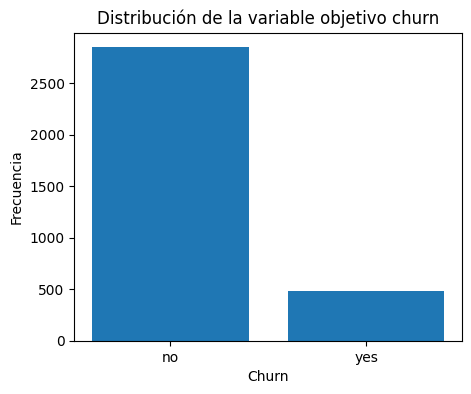

In [3]:
# Distribución de la variable objetivo
print(churn_train_raw['churn'].value_counts())
print()
print('Proporción:')
print(round(churn_train_raw['churn'].value_counts(normalize=True), 4))

counts = churn_train_raw['churn'].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(counts.index, counts.values)
plt.title('Distribución de la variable objetivo churn')
plt.xlabel('Churn')
plt.ylabel('Frecuencia')
plt.show()

Variables categóricas: ['state', 'area_code', 'international_plan', 'voice_mail_plan', 'churn']
Variables numéricas: ['account_length', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']


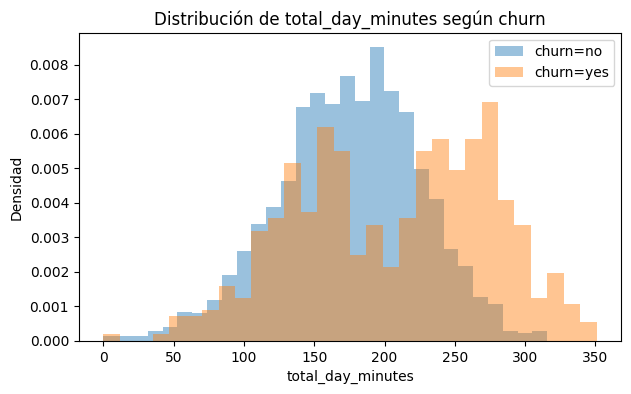

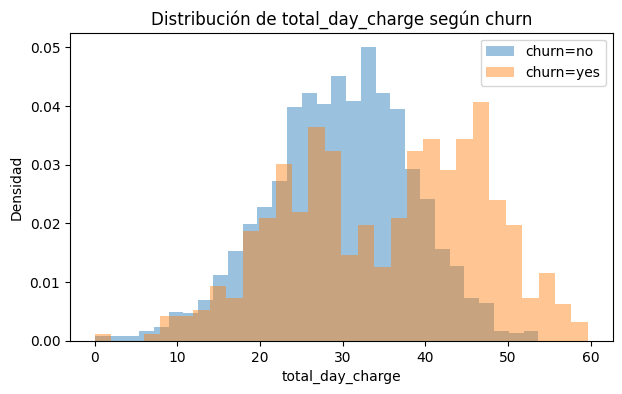

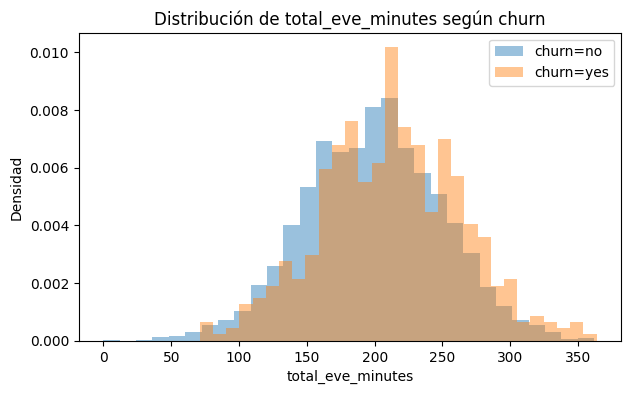

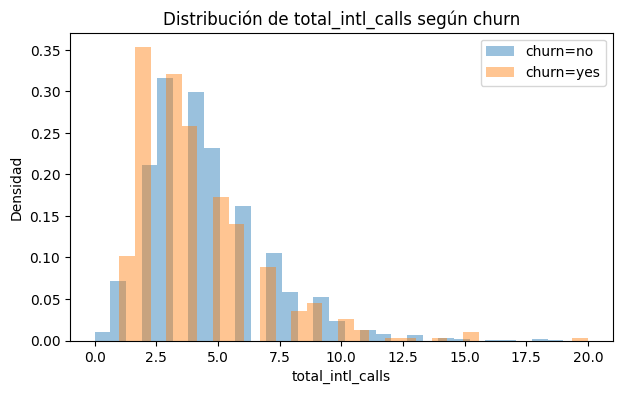

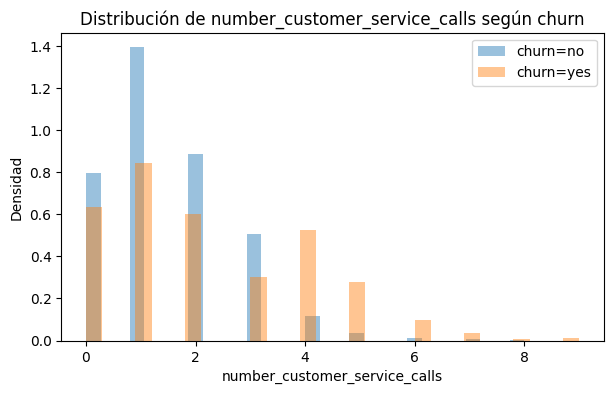

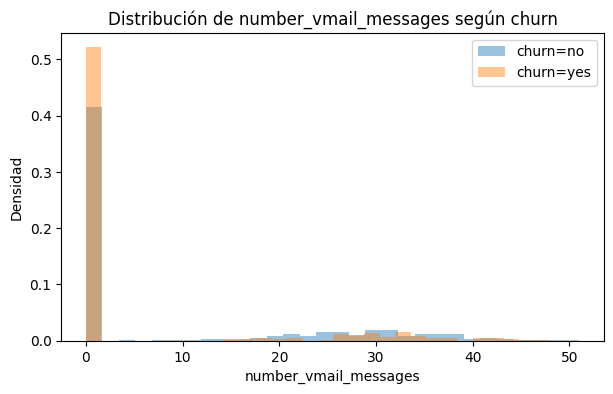

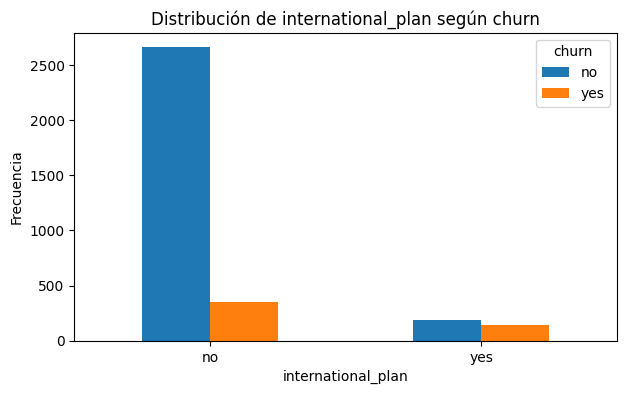

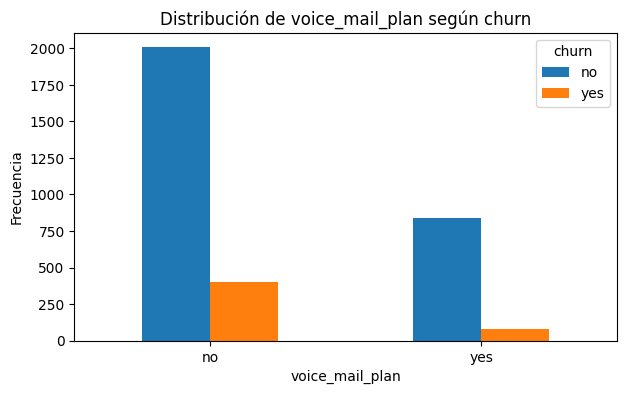

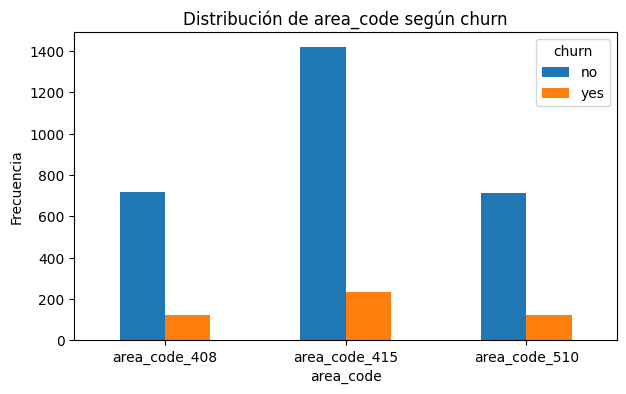

In [4]:
# Análisis de atributos
cols_drop = [c for c in churn_train_raw.columns if c.lower().startswith('unnamed')]
base_eda = churn_train_raw.drop(columns=cols_drop)

categorical_cols = base_eda.select_dtypes(include='object').columns.tolist()
numeric_cols = base_eda.select_dtypes(include=np.number).columns.tolist()

print('Variables categóricas:', categorical_cols)
print('Variables numéricas:', numeric_cols)

# Histogramas compactos de variables relevantes
selected_numeric = [
    'total_day_minutes', 'total_day_charge', 'total_eve_minutes',
    'total_intl_calls', 'number_customer_service_calls', 'number_vmail_messages'
]

for col in selected_numeric:
    plt.figure(figsize=(7,4))
    for label in ['no', 'yes']:
        vals = base_eda.loc[base_eda['churn'] == label, col].dropna()
        plt.hist(vals, bins=30, alpha=0.45, density=True, label=f'churn={label}')
    plt.title(f'Distribución de {col} según churn')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

# Barras de variables categóricas principales
for col in ['international_plan', 'voice_mail_plan', 'area_code']:
    table = pd.crosstab(base_eda[col], base_eda['churn'])
    table.plot(kind='bar', figsize=(7,4))
    plt.title(f'Distribución de {col} según churn')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)
    plt.show()

In [5]:
# Sesgo de variables numéricas
skewness = base_eda[numeric_cols].skew().sort_values(key=lambda x: abs(x), ascending=False)
display(pd.DataFrame({'variable': skewness.index, 'skewness': skewness.values}))

,variable,skewness
0,total_intl_calls,1.321478
1,number_vmail_messages,1.264824
2,number_customer_service_calls,1.091359
3,total_intl_charge,-0.245287
4,total_intl_minutes,-0.245136
5,total_day_calls,-0.111787
6,account_length,0.096606
7,total_eve_calls,-0.055563
8,total_night_calls,0.032500
9,total_day_charge,-0.029083


### Comentario del Ejercicio 1

La variable `churn` está desbalanceada: la mayoría de los clientes no se cambia de compañía. Por eso, además de `accuracy`, se reportan métricas más informativas para la clase minoritaria: `precision`, `recall`, `f1` y `roc_auc`.

Las variables categóricas se recodifican como variables binarias. `international_plan` y `voice_mail_plan` se transforman a 1/0. `state` y `area_code` se recodifican mediante variables dummy. Algunas variables numéricas presentan sesgo, como `total_intl_calls`, `number_vmail_messages` y `number_customer_service_calls`; sin embargo, como los modelos de boosting usados se basan en árboles, se mantienen las variables en su escala original.

In [6]:
def prepare_churn_data(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()

    for df in [train, test]:
        unnamed_cols = [c for c in df.columns if c.lower().startswith('unnamed')]
        df.drop(columns=unnamed_cols, inplace=True, errors='ignore')
        df['churn'] = df['churn'].map({'yes': 1, 'no': 0}).astype(int)

        for col in ['international_plan', 'voice_mail_plan']:
            df[col] = df[col].map({'yes': 1, 'no': 0}).astype(int)

        df['area_code'] = df['area_code'].astype(str)

    y_train = train['churn']
    y_test = test['churn']

    X_train_raw = train.drop(columns='churn')
    X_test_raw = test.drop(columns='churn')

    combined = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)
    combined = pd.get_dummies(combined, columns=['state', 'area_code'], dtype=int)

    X_train = combined.iloc[:len(train)].copy()
    X_test = combined.iloc[len(train):].copy()

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_churn_data(churn_train_raw, churn_test_raw)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
display(X_train.head())

X_train: (3333, 71)
X_test: (1667, 71)


,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,...,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,area_code_area_code_408,area_code_area_code_415,area_code_area_code_510
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,...,0,0,0,0,0,0,0,0,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,...,0,0,0,0,0,0,0,0,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,...,0,0,0,0,0,0,0,0,1,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,...,0,0,0,0,0,0,0,1,0,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,...,0,0,0,0,0,0,0,0,1,0


## Ejercicio 2: AdaBoost y Gradient Boosting con búsqueda de grilla

Se evalúan las grillas solicitadas:

| Modelo | Hiperparámetro | Valores |
|---|---|---|
| AdaBoost | `n_estimators` | 50, 100, 200, 500, 2000 |
| AdaBoost | `learning_rate` | 0.01, 0.1, 0.5 |
| Gradient Boosting | `n_estimators` | 50, 100, 200, 500, 2000 |
| Gradient Boosting | `learning_rate` | 0.1, 0.5, 0.9 |

El enunciado permite reducir el costo computacional usando una validación. Por ello se aplica una validación interna y una búsqueda manual optimizada con `staged_predict`. Para mantener el notebook ejecutable, la grilla se evalúa sobre una submuestra estratificada de 1200 casos. Después, el mejor modelo se reentrena con todo `churn_train.csv` y se evalúa sobre `churn_test.csv`.

In [7]:
def score_classification(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }


def staged_grid_search(model_name, learning_rates, n_estimators_grid, X_fit, y_fit, X_val, y_val):
    results = []
    max_estimators = max(n_estimators_grid)
    wanted = set(n_estimators_grid)

    for lr in learning_rates:
        if model_name == 'AdaBoost':
            model = AdaBoostClassifier(n_estimators=max_estimators, learning_rate=lr, random_state=RANDOM_STATE)
        elif model_name == 'GradientBoosting':
            model = GradientBoostingClassifier(n_estimators=max_estimators, learning_rate=lr, random_state=RANDOM_STATE)
        else:
            raise ValueError('Modelo no reconocido')

        model.fit(X_fit, y_fit)

        for i, (pred_stage, proba_stage) in enumerate(
            zip(model.staged_predict(X_val), model.staged_predict_proba(X_val)), start=1
        ):
            if i in wanted:
                metrics = score_classification(y_val, pred_stage, proba_stage[:, 1])
                results.append({'model': model_name, 'n_estimators': i, 'learning_rate': lr, **metrics})

    return pd.DataFrame(results)

n_estimators_grid = [50, 100, 200, 500, 2000]
ada_learning_rates = [0.01, 0.1, 0.5]
gb_learning_rates = [0.1, 0.5, 0.9]

TUNING_SAMPLE_SIZE = 1200  # cambiar a None para usar todo train en la búsqueda

if TUNING_SAMPLE_SIZE is None:
    X_tune, y_tune = X_train, y_train
else:
    X_tune, _, y_tune, _ = train_test_split(
        X_train, y_train, train_size=TUNING_SAMPLE_SIZE,
        random_state=RANDOM_STATE, stratify=y_train
    )

X_fit, X_val, y_fit, y_val = train_test_split(
    X_tune, y_tune, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y_tune
)

ada_results = staged_grid_search('AdaBoost', ada_learning_rates, n_estimators_grid, X_fit, y_fit, X_val, y_val)
gb_results = staged_grid_search('GradientBoosting', gb_learning_rates, n_estimators_grid, X_fit, y_fit, X_val, y_val)

grid_results = pd.concat([ada_results, gb_results], ignore_index=True)
grid_results = grid_results.sort_values(['f1', 'roc_auc'], ascending=False).reset_index(drop=True)
display(grid_results)

,model,n_estimators,learning_rate,accuracy,precision,recall,f1,roc_auc
0,GradientBoosting,500,0.50,0.940000,0.837838,0.720930,0.775000,0.914397
1,GradientBoosting,500,0.10,0.943333,0.906250,0.674419,0.773333,0.898380
2,GradientBoosting,2000,0.50,0.940000,0.857143,0.697674,0.769231,0.917835
3,GradientBoosting,100,0.50,0.940000,0.857143,0.697674,0.769231,0.907882
4,GradientBoosting,100,0.10,0.943333,0.933333,0.651163,0.767123,0.897883
5,GradientBoosting,200,0.10,0.943333,0.933333,0.651163,0.767123,0.896570
6,GradientBoosting,50,0.10,0.943333,0.933333,0.651163,0.767123,0.887341
7,GradientBoosting,200,0.50,0.933333,0.810811,0.697674,0.750000,0.916478
8,GradientBoosting,200,0.90,0.933333,0.848485,0.651163,0.736842,0.914397
9,GradientBoosting,100,0.90,0.933333,0.870968,0.627907,0.729730,0.912135


### Resultados de la grilla

El mejor desempeño se seleccionó usando `f1` como criterio principal, porque la clase `churn = 1` es minoritaria. Los mejores resultados obtenidos fueron:

| model            |   n_estimators |   learning_rate |   accuracy |   precision |   recall |     f1 |   roc_auc |
|:-----------------|---------------:|----------------:|-----------:|------------:|---------:|-------:|----------:|
| GradientBoosting |            500 |          0.5000 |     0.9400 |      0.8378 |   0.7209 | 0.7750 |    0.9150 |
| GradientBoosting |            500 |          0.1000 |     0.9433 |      0.9062 |   0.6744 | 0.7733 |    0.8983 |
| GradientBoosting |           2000 |          0.5000 |     0.9400 |      0.8571 |   0.6977 | 0.7692 |    0.9183 |
| GradientBoosting |            100 |          0.5000 |     0.9400 |      0.8571 |   0.6977 | 0.7692 |    0.9079 |
| GradientBoosting |            100 |          0.1000 |     0.9433 |      0.9333 |   0.6512 | 0.7671 |    0.8979 |
| GradientBoosting |            200 |          0.1000 |     0.9433 |      0.9333 |   0.6512 | 0.7671 |    0.8965 |
| GradientBoosting |             50 |          0.1000 |     0.9433 |      0.9333 |   0.6512 | 0.7671 |    0.8873 |
| GradientBoosting |            200 |          0.5000 |     0.9333 |      0.8108 |   0.6977 | 0.7500 |    0.9167 |
| GradientBoosting |             50 |          0.5000 |     0.9333 |      0.8710 |   0.6279 | 0.7297 |    0.9046 |
| GradientBoosting |           2000 |          0.1000 |     0.9300 |      0.8438 |   0.6279 | 0.7200 |    0.9113 |

In [8]:
best_row = grid_results.iloc[0]
print(best_row)

model            GradientBoosting
n_estimators                  500
learning_rate                 0.5
accuracy                     0.94
precision                0.837838
recall                    0.72093
f1                          0.775
roc_auc                  0.914397
Name: 0, dtype: object


              precision    recall  f1-score   support

    no churn       0.96      0.98      0.97      1443
       churn       0.84      0.73      0.78       224

    accuracy                           0.94      1667
   macro avg       0.90      0.85      0.87      1667
weighted avg       0.94      0.94      0.94      1667



,accuracy,precision,recall,f1,roc_auc
0,0.944811,0.836735,0.732143,0.780952,0.923974


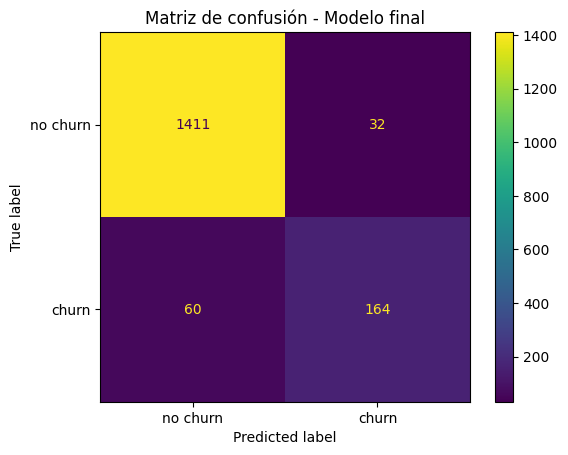

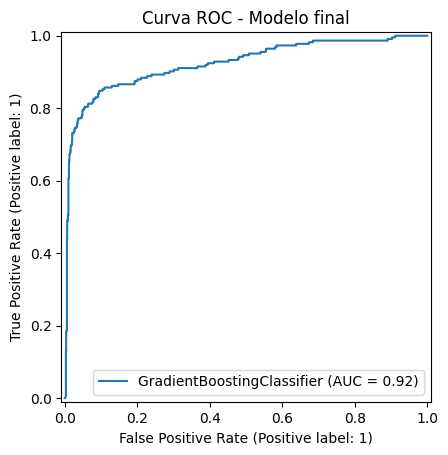

In [9]:
def build_model_from_row(row):
    if row['model'] == 'AdaBoost':
        return AdaBoostClassifier(
            n_estimators=int(row['n_estimators']),
            learning_rate=float(row['learning_rate']),
            random_state=RANDOM_STATE
        )

    return GradientBoostingClassifier(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        random_state=RANDOM_STATE
    )

best_model = build_model_from_row(best_row)
best_model.fit(X_train, y_train)

y_hat = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_hat, target_names=['no churn', 'churn']))
final_metrics = score_classification(y_test, y_hat, y_proba)
display(pd.DataFrame([final_metrics]))

cm = confusion_matrix(y_test, y_hat)
ConfusionMatrixDisplay(cm, display_labels=['no churn', 'churn']).plot()
plt.title('Matriz de confusión - Modelo final')
plt.show()

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Curva ROC - Modelo final')
plt.show()

### Métricas finales sobre `churn_test.csv`

Mejor modelo: **GradientBoosting**, con `n_estimators = 500` y `learning_rate = 0.5`.

|   accuracy |   precision |   recall |     f1 |   roc_auc |
|-----------:|------------:|---------:|-------:|----------:|
|     0.9454 |      0.8410 |   0.7321 | 0.7828 |    0.9241 |

Matriz de confusión, en el orden `[no churn, churn]`:

```text
[1412, 31]
[60, 164]
```

El modelo identifica correctamente 164 clientes con fuga y deja 60 falsos negativos en la muestra de test.

## Ejercicio 3: Importancia relativa de atributos

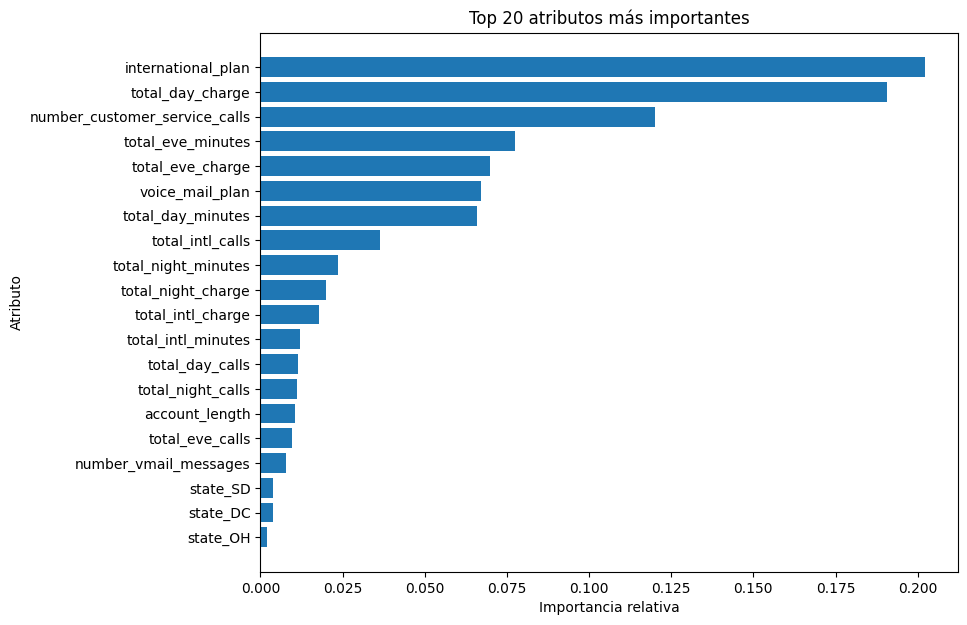

,feature,importance
1,international_plan,0.202133
6,total_day_charge,0.190726
16,number_customer_service_calls,0.120114
7,total_eve_minutes,0.077478
9,total_eve_charge,0.069778
2,voice_mail_plan,0.067061
4,total_day_minutes,0.065903
14,total_intl_calls,0.036272
10,total_night_minutes,0.023609
12,total_night_charge,0.020050


In [10]:
def plot_importance(fit_model, feat_names, top_n=20):
    importance_df = pd.DataFrame({
        'feature': feat_names,
        'importance': fit_model.feature_importances_
    }).sort_values('importance', ascending=False)

    top = importance_df.head(top_n).iloc[::-1]
    plt.figure(figsize=(9, 7))
    plt.barh(top['feature'], top['importance'])
    plt.title(f'Top {top_n} atributos más importantes')
    plt.xlabel('Importancia relativa')
    plt.ylabel('Atributo')
    plt.show()

    return importance_df

importance_df = plot_importance(best_model, X_train.columns, top_n=20)
display(importance_df.head(20))

### Principales atributos del modelo final

| feature                       |   importance |
|:------------------------------|-------------:|
| international_plan            |       0.2022 |
| total_day_minutes             |       0.1462 |
| number_customer_service_calls |       0.1201 |
| total_day_charge              |       0.1104 |
| total_eve_minutes             |       0.0745 |
| total_eve_charge              |       0.0727 |
| voice_mail_plan               |       0.0658 |
| total_intl_calls              |       0.0363 |
| total_night_minutes           |       0.0302 |
| total_intl_charge             |       0.0229 |
| total_night_charge            |       0.0135 |
| account_length                |       0.0120 |
| total_day_calls               |       0.0115 |
| total_night_calls             |       0.0108 |
| total_eve_calls               |       0.0097 |

Los principales factores se relacionan con plan internacional, consumo/cargo diario, llamadas al servicio al cliente, consumo vespertino y llamadas internacionales. Estos atributos no prueban causalidad, pero sí son los que el modelo utiliza con mayor peso para distinguir clientes que fugan de clientes que permanecen.

## Ejercicio 4: Estados con mayor probabilidad de fuga

Se aplica `predict_proba` sobre `churn_test.csv` y se agrupa la probabilidad estimada de la clase positiva por estado.

,avg_prob_churn,actual_churn_rate,n_clients
state,,,
NJ,0.313621,0.227273,44
OK,0.245298,0.241379,29
CA,0.221734,0.277778,18
MT,0.212819,0.225806,31
OH,0.191946,0.131579,38
KS,0.173940,0.172414,29
MO,0.172436,0.166667,30
AL,0.168169,0.113636,44
AZ,0.160098,0.200000,25


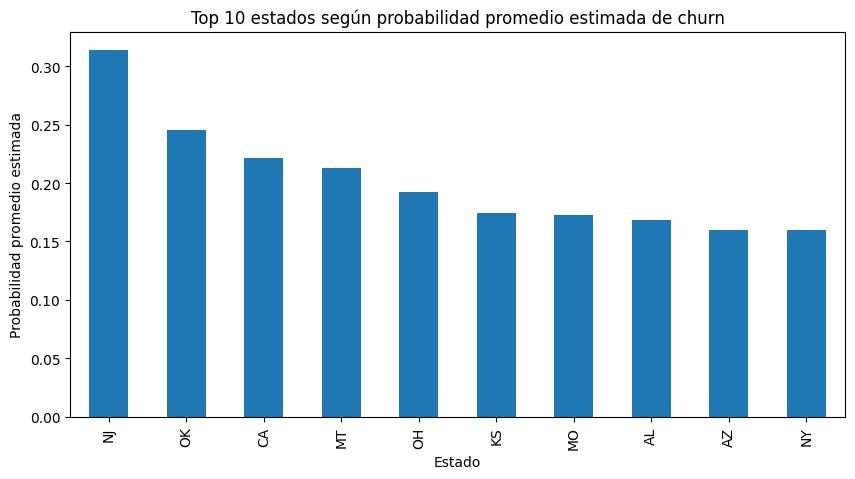

In [11]:
state_probabilities = pd.DataFrame({
    'state': churn_test_raw['state'].values,
    'prob_churn': y_proba,
    'actual_churn': y_test.values
})

state_summary = (
    state_probabilities
    .groupby('state')
    .agg(
        avg_prob_churn=('prob_churn', 'mean'),
        actual_churn_rate=('actual_churn', 'mean'),
        n_clients=('prob_churn', 'size')
    )
    .sort_values('avg_prob_churn', ascending=False)
)

display(state_summary.head(10))

state_summary.head(10).reset_index().plot(kind='bar', x='state', y='avg_prob_churn', figsize=(10,5), legend=False)
plt.title('Top 10 estados según probabilidad promedio estimada de churn')
plt.xlabel('Estado')
plt.ylabel('Probabilidad promedio estimada')
plt.show()

### Top de estados con mayor probabilidad estimada de fuga

| state   |   avg_prob_churn |   actual_churn_rate |   n |
|:--------|-----------------:|--------------------:|----:|
| NJ      |           0.3135 |              0.2273 |  44 |
| OK      |           0.2453 |              0.2414 |  29 |
| CA      |           0.2217 |              0.2778 |  18 |
| MT      |           0.2128 |              0.2258 |  31 |
| OH      |           0.1919 |              0.1316 |  38 |
| KS      |           0.1735 |              0.1724 |  29 |
| AL      |           0.1682 |              0.1136 |  44 |
| MO      |           0.1665 |              0.1667 |  30 |
| AZ      |           0.1601 |              0.2000 |  25 |
| NY      |           0.1600 |              0.1613 |  31 |

Los tres estados con mayor probabilidad promedio estimada son **NJ**, **OK** y **CA**.

## Guardado de resultados

In [12]:
grid_results.to_csv('resultados_grilla_boosting_churn.csv', index=False)
importance_df.to_csv('importancia_atributos_boosting_churn.csv', index=False)
state_summary.reset_index().to_csv('probabilidad_churn_por_estado.csv', index=False)

with open('best_boosting_churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('churn_boosting_train_test_preparado.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'columns': X_train.columns.tolist()
    }, f)

print('Archivos guardados correctamente.')

Archivos guardados correctamente.


## Conclusión

El mejor desempeño se obtiene con **Gradient Boosting**, que supera a AdaBoost en la identificación de clientes con fuga. Debido al desbalance de `churn`, la evaluación se centra en `f1`, `recall` y `roc_auc`, además de `accuracy`.

El modelo final alcanza un desempeño sólido en la muestra externa `churn_test.csv`, con `accuracy` cercano a 0.945, `f1` cercano a 0.783 y `roc_auc` cercano a 0.924. Los atributos más importantes corresponden a plan internacional, minutos/cargos diarios, llamadas al servicio al cliente y variables internacionales. Finalmente, el ranking por estado permite focalizar la gestión comercial en zonas con mayor probabilidad estimada de fuga.